# Group-based split comparison

This notebook checks whether the current image and multimodal splits allow overlap of document groups across train, validation, and test, and compares them with a group-based alternative using `group_key`.

In [3]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

In [4]:
image_train_old = pd.read_csv(processed_dir / "image_train.csv")
image_val_old = pd.read_csv(processed_dir / "image_val.csv")
image_test_old = pd.read_csv(processed_dir / "image_test.csv")

image_train_new = pd.read_csv(processed_dir / "image_train_group_test.csv")
image_val_new = pd.read_csv(processed_dir / "image_val_group_test.csv")
image_test_new = pd.read_csv(processed_dir / "image_test_group_test.csv")

mm_train_old = pd.read_csv(processed_dir / "mm_train.csv")
mm_val_old = pd.read_csv(processed_dir / "mm_val.csv")
mm_test_old = pd.read_csv(processed_dir / "mm_test.csv")

mm_train_new = pd.read_csv(processed_dir / "mm_train_group_test.csv")
mm_val_new = pd.read_csv(processed_dir / "mm_val_group_test.csv")
mm_test_new = pd.read_csv(processed_dir / "mm_test_group_test.csv")

## Example of one document group

The same `group_key` can contain several related samples from the same underlying document.

In [6]:
full_df = pd.read_csv(processed_dir / "image_dataset_final.csv")

example = full_df[full_df["group_key"] == "arabic-003_03"][
    ["source_dataset", "image_class", "source_type", "file_name", "image_path"]
].sort_values(["image_class", "image_path"])

example

,source_dataset,image_class,source_type,file_name,image_path
6651,fantasyid,bona_fide,huawei,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
6862,fantasyid,bona_fide,iphone15pro,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
7073,fantasyid,bona_fide,scan,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
4000,fantasyid,forged,huawei,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
4262,fantasyid,forged,iphone15pro,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
4524,fantasyid,forged,scan,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
5385,fantasyid,forged,huawei,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
5596,fantasyid,forged,iphone15pro,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
5807,fantasyid,forged,scan,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
6018,fantasyid,forged,huawei,arabic-003_03.jpg,C:\Users\Admin\Desktop\thesis\multimodal-fraud...


## Overlap in the current image split

In [7]:
old_train_groups = set(image_train_old["group_key"])
old_val_groups = set(image_val_old["group_key"])
old_test_groups = set(image_test_old["group_key"])

print("Train-Val overlap:", len(old_train_groups & old_val_groups))
print("Train-Test overlap:", len(old_train_groups & old_test_groups))
print("Val-Test overlap:", len(old_val_groups & old_test_groups))

Train-Val overlap: 118
Train-Test overlap: 287
Val-Test overlap: 57


## Overlap in the group-based image split

In [8]:
new_train_groups = set(image_train_new["group_key"])
new_val_groups = set(image_val_new["group_key"])
new_test_groups = set(image_test_new["group_key"])

print("Train-Val overlap:", len(new_train_groups & new_val_groups))
print("Train-Test overlap:", len(new_train_groups & new_test_groups))
print("Val-Test overlap:", len(new_val_groups & new_test_groups))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


## Old vs new image split statistics

In [9]:
def split_summary(name, df):
    return {
        "split": name,
        "rows": len(df),
        "groups": df["group_key"].nunique(),
        "bona_fide": (df["image_class"] == "bona_fide").sum(),
        "forged": (df["image_class"] == "forged").sum(),
    }

image_summary = pd.DataFrame([
    split_summary("old_train", image_train_old),
    split_summary("old_val", image_val_old),
    split_summary("old_test", image_test_old),
    split_summary("new_train", image_train_new),
    split_summary("new_val", image_val_new),
    split_summary("new_test", image_test_new),
])

image_summary

,split,rows,groups,bona_fide,forged
0,old_train,6320,915,3300,3020
1,old_val,1419,296,729,690
2,old_test,2425,613,904,1521
3,new_train,7182,953,3451,3731
4,new_val,1508,204,743,765
5,new_test,1474,205,739,735


This table shows how the image split changed after switching from row-based splitting to group-based splitting.

In the old version, individual image rows were split directly. In the new version, all images from the same document group were kept together in one subset. Because of this, the number of rows in train, validation, and test changed.

It should be better because it prevents similar images from the same document from being split across train, validation, and test, which leads to more clean and reliable e results.

## Old vs new multimodal split statistics

In [12]:
def mm_summary(name, df):
    return {
        "split": name,
        "rows": len(df),
        "label_0": (df["final_label"] == 0).sum(),
        "label_1": (df["final_label"] == 1).sum(),
    }

mm_summary_df = pd.DataFrame([
    mm_summary("old_train", mm_train_old),
    mm_summary("old_val", mm_val_old),
    mm_summary("old_test", mm_test_old),
    mm_summary("new_train", mm_train_new),
    mm_summary("new_val", mm_val_new),
    mm_summary("new_test", mm_test_new),
])

mm_summary_df
print(mm_summary_df)

       split  rows  label_0  label_1
0  old_train  6320     3300     3020
1    old_val  1419      729      690
2   old_test  2425      904     1521
3  new_train  7182     3451     3731
4    new_val  1508      743      765
5   new_test  1474      739      735


This table compares the old and new multimodal splits. After switching to the group-based image split, the multimodal train, validation, and test sets also changed, because multimodal pairing depends on the image split.

The new version is better balanced, especially in the test set. In the old split, the test set had many more label 1 samples than label 0 samples. In the new split, the test set is almost evenly balanced. Here, label 1 corresponds to fraud/forged samples, while label 0 corresponds to bonafide samples.

## Overlap in the multimodal splits

In [11]:
old_train_groups = set(mm_train_old["img_group_key"])
old_val_groups = set(mm_val_old["img_group_key"])
old_test_groups = set(mm_test_old["img_group_key"])

new_train_groups = set(mm_train_new["img_group_key"])
new_val_groups = set(mm_val_new["img_group_key"])
new_test_groups = set(mm_test_new["img_group_key"])

print("OLD MM overlap")
print("Train-Val:", len(old_train_groups & old_val_groups))
print("Train-Test:", len(old_train_groups & old_test_groups))
print("Val-Test:", len(old_val_groups & old_test_groups))

print("\nNEW MM overlap")
print("Train-Val:", len(new_train_groups & new_val_groups))
print("Train-Test:", len(new_train_groups & new_test_groups))
print("Val-Test:", len(new_val_groups & new_test_groups))

OLD MM overlap
Train-Val: 118
Train-Test: 287
Val-Test: 57

NEW MM overlap
Train-Val: 0
Train-Test: 0
Val-Test: 0


## Conclusion

Overall, the group-based split is preferable because it removes overlap between related document groups and produces a cleaner and more balanced basis for image and multimodal evaluation.

# Does the model perform differently when trained and tested on the old row-based split versus the new group-based split?


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis")

# Try to find the results file
possible_results = list(PROJECT_ROOT.rglob("visual_pipeline_compare_results.json"))

if not possible_results:
    raise FileNotFoundError(
        "visual_pipeline_compare_results.json was not found. "
        "You need to run train_visual_pipeline_compare.py first."
    )

results_path = possible_results[0]
print("Loading results from:", results_path)

with open(results_path, "r") as f:
    results = json.load(f)

rows = []

for exp_name, r in results.items():
    m = r["test_metrics"]

    rows.append({
        "experiment": "Old splits (random CV)" if "old" in exp_name.lower() else "New splits (group CV)",
        "split_type": "Old (random/leaky)" if "old" in exp_name.lower() else "New (group-based/clean)",
        "train_rows": r.get("train_rows"),
        "test_rows": r.get("test_rows"),
        "overlap": r.get("train_test_overlap"),
        "best_cv_f1": r.get("best_cv_score_f1"),
        "accuracy": m.get("accuracy"),
        "precision": m.get("precision"),
        "recall": m.get("recall"),
        "f1": m.get("f1"),
        "roc_auc": m.get("roc_auc"),
    })

cmp_df = pd.DataFrame(rows)

display(
    cmp_df[
        ["experiment", "split_type", "overlap", "accuracy", "precision", "recall", "f1", "roc_auc"]
    ].round(4)
)

Loading results from: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\visual_pipeline_compare_results.json


,experiment,split_type,overlap,accuracy,precision,recall,f1,roc_auc
0,Old splits (random CV),Old (random/leaky),287,0.7913,0.9677,0.6903,0.8058,0.9477
1,New splits (group CV),New (group-based/clean),0,0.9179,0.8800,0.9673,0.9216,0.9731


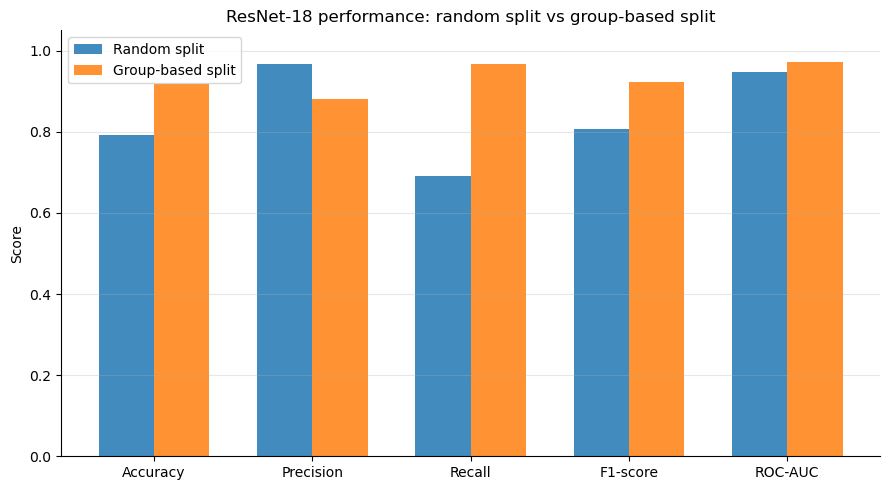

In [3]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.35

old_row = cmp_df[cmp_df["split_type"].str.contains("Old")].iloc[0]
new_row = cmp_df[cmp_df["split_type"].str.contains("New")].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    [old_row[m] for m in metrics],
    width,
    label="Random split",
    alpha=0.85
)

ax.bar(
    x + width / 2,
    [new_row[m] for m in metrics],
    width,
    label="Group-based split",
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ResNet-18 performance: random split vs group-based split")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("resnet_random_vs_grouped_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
print("Random split performance:")
print(old_row[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

print("\nGroup-based split performance:")
print(new_row[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

print("\nDifference: random minus group-based")
for m in metrics:
    diff = old_row[m] - new_row[m]
    print(f"{m}: {diff:+.4f}")

if old_row["f1"] > new_row["f1"]:
    print(
        "\nConclusion: ResNet performs better on the random split, "
        "but this performance is likely inflated because the random split contains data leakage."
    )
else:
    print(
        "\nConclusion: ResNet performs better on the group-based split."
    )

Random split performance:
accuracy      0.79134
precision    0.967742
recall       0.690335
f1           0.805833
roc_auc      0.947676
Name: 0, dtype: object

Group-based split performance:
accuracy      0.91791
precision     0.87995
recall       0.967347
f1           0.921581
roc_auc      0.973074
Name: 1, dtype: object

Difference: random minus group-based
accuracy: -0.1266
precision: +0.0878
recall: -0.2770
f1: -0.1157
roc_auc: -0.0254

Conclusion: ResNet performs better on the group-based split.


In this experiment, the group-based split achieved stronger overall performance than the random split, while also eliminating document-group overlap. The group-based strategy is both methodologically cleaner and empirically more effective for this ResNet-18.